In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm, expm_multiply, spsolve, norm
from utils import *
from linear_system_std_binary import *

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import Aer
from qiskit.circuit.library import QFT
from ionq_circuit_utils import save_as_native_circuit

from pytket import OpType, Circuit
from pytket.circuit import StatePreparationBox
from pytket.passes import DecomposeBoxes, RebaseCustom, RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk, tk_to_qiskit
from pytket.circuit.display import render_circuit_jupyter

Circuit Optimization
- step 1: convert to GPi, GPi2, AAMS
- step 2: check if commute and $|\cos(\phi)|<|\sin(\phi)|$ to move AAMS gates to front
- step 3: combine AAMS gates

In [45]:
# circuit = QuantumCircuit(2)
# circuit.rxx(0.2, 0, 1)
# circuit.rx(0.1, 0)
# circuit.rxx(0.2, 0, 1)
# circuit.rx(0.1, 0)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'rz', 'rxx'], optimization_level=3)
# print(compiled_circuit.count_ops())

# Test theta_i (XX + YY)
circuit = QuantumCircuit(2)
r = 5
np.random.seed(0)
theta = np.random.rand(r)
for i in range(r):
    # circuit.rxx(theta[i], 0, 1)
    # # circuit.ryy(theta[i], 0, 1)
    # circuit.rz(-np.pi/2, 0)
    # circuit.rz(-np.pi/2, 1)
    # circuit.rxx(theta[i], 0, 1)
    # circuit.rz(np.pi/2, 0)
    # circuit.rz(np.pi/2, 1)
    circuit.rx(theta[i], 0)
    circuit.ry(theta[i], 0)

compiled_circuit = transpile(circuit, basis_gates=['rx', "ry", 'rz', 'rxx', 'ryy'], optimization_level=1)
print(compiled_circuit.count_ops())
tket_circuit = qiskit_to_tk(compiled_circuit)
gateset = {OpType.Rx, OpType.Rz, OpType.XXPhase}
rebase = auto_rebase_pass(gateset)
comp = RepeatPass(SequencePass([rebase, CommuteThroughMultis(), RemoveRedundancies()]))
comp.apply(tket_circuit)
num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
print(num_single_qubit_gates, num_two_qubit_gates)


OrderedDict([('rz', 2), ('ry', 1)])
3 0


In [46]:
compiled_circuit.draw()

global phase: π
     ┌─────────────┐┌───────────┐┌────────────┐
q_0: ┤ Rz(-1.9153) ├┤ Ry(2.194) ├┤ Rz(2.8682) ├
     └─────────────┘└───────────┘└────────────┘
q_1: ──────────────────────────────────────────

In [29]:
N_p = 2 ** n_p
p = np.linspace(-R, R, N_p)

amplitude_vector_left = np.exp(-np.abs(p))[:2**(n_p - 1)]
amplitude_vector_left /= np.linalg.norm(amplitude_vector_left)
q = QuantumRegister(n_p)
state_prep_circuit = QuantumCircuit(q)
state_prep_circuit.initialize(amplitude_vector_left, [q[j] for j in range(n_p-1)])
# Make symmetric
state_prep_circuit.h(n_p - 1)
for i in range(n_p-1):
    state_prep_circuit.cnot(n_p - 1, i)

state_prep_circuit.append(QFT(n_p).inverse(), qargs=list(range(n_p)))


# Generate linear system

In [11]:
H_1 = sum_h_x(n=2, h=np.array([2, 3])) + sum_h_z(n=2, h=np.array([-5, -6]))
H_1 = sum_h_x(n=2, h=np.array([2, 3])) + sum_h_z(n=2, h=np.array([-2, -3]))
H_1 -= H_1[-1,-1] * eye(4)
assert H_1[-1,-1] == 0
A = -H_1[:3,:3]
A_norm = np.linalg.norm(A.toarray(), ord=2)
H_1 /= A_norm
A /= A_norm
print("A:\n", A.toarray())
evals = eigvalsh(A.toarray())
print("Eigenvalues:", evals)
print(f"Condition number: {np.max(evals) / np.min(evals)}")
assert np.all(eigvalsh(A.toarray()) > 0)
b = 2 * H_1[:-1,-1]

print("b:\n", b.toarray())
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
dimension = 3

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

A:
 [[ 0.84499602 -0.1689992  -0.25349881]
 [-0.1689992   0.50699761  0.        ]
 [-0.25349881  0.          0.33799841]]
Eigenvalues: [0.21672283 0.47326922 1.        ]
Condition number: 4.6141886213324
b:
 [[0.        ]
 [0.50699761]
 [0.33799841]]
Ground truth: [0.70588235 1.23529412 1.52941176]


In [12]:
# R = 7
# n_p = 6
R = 6
n_p = 6
# R = 3.5
# n_p = 4
N_p = 2 ** n_p
h = (2 * R) / (N_p - 1)
p = np.linspace(-R, R, N_p)

n_x = int(np.log2(A_tilde.shape[0]))
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
T = 5
# T = 5
N_t = 16
# r = 2
r = 2
u_recover = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
# print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

N_p: 64
Total number of qubits: 8
Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
(256, 256)
Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
Norm of diff:  0.00
Trotter error:  0.83
Relative error (Schrodingerization):  0.194
Relative error (Schrodingerization with FT):  0.190


In [21]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method="second_order")
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

Depth: 80
OrderedDict([('rxx', 91), ('ry', 56), ('rz', 41), ('rx', 26), ('swap', 6)])


Ground truth

In [14]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-1.        +0.j -0.21672283+0.j -0.47326922+0.j  0.        +0.j]
[-1.02000043 -0.5419985  -0.30299753  0.17500441]


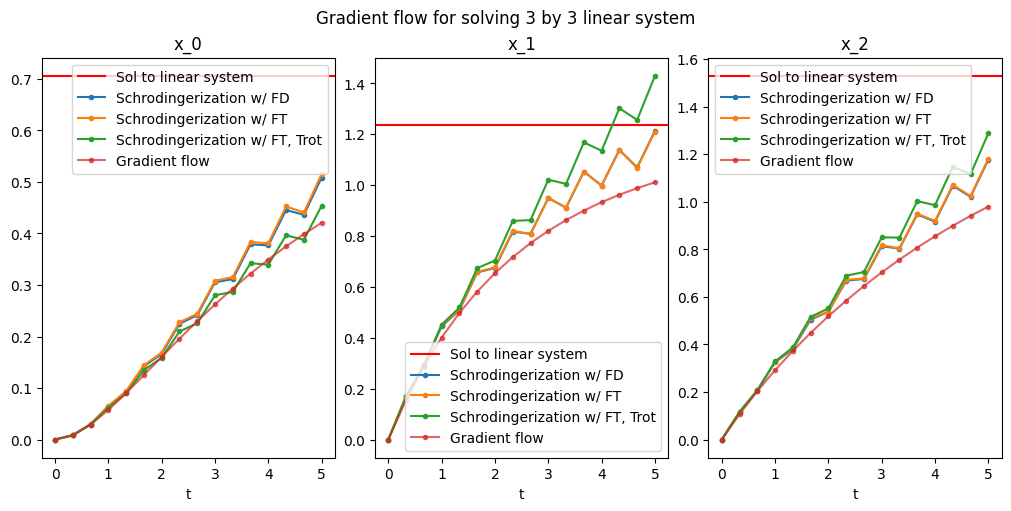

In [15]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [7]:
# x,y,z = np.random.randn(), np.random.randn(), np.random.randn()
# a_vec = np.array([x,y,z])
# norm = np.linalg.norm(a_vec)
# a_vec /= norm
# x /= norm
# y /= norm
# z /= norm
# print(a_vec)
# theta = np.arctan2(y, x)
# print(theta)

In [8]:
# theta = np.random.randn()
# phi = np.random.randn()
# A = expm(-1j * (theta / 2) * (np.cos(phi) * PAULI_Z + np.sin(phi) * PAULI_X))
# B = expm(-1j * (-((np.pi / 2 - phi)) / 2) * PAULI_Y) @ expm(-1j * (theta / 2) * (PAULI_X)) @ expm(-1j * ((np.pi / 2 - phi) / 2) * PAULI_Y)
# np.abs(np.trace(A.toarray() @ np.conj(B.toarray().T)) / 2)

In [9]:
# theta = np.random.randn()
# phi = np.random.randn()
# A = expm(-1j * (theta / 2) * (np.cos(phi) * PAULI_X + np.sin(phi) * PAULI_Z))
# B = expm(-1j * (-(phi) / 2) * PAULI_Y) @ expm(-1j * (theta / 2) * (PAULI_X)) @ expm(-1j * ((phi) / 2) * PAULI_Y)
# np.abs(np.trace(A.toarray() @ np.conj(B.toarray().T)) / 2)

In [10]:
# theta = np.random.rand()
# A = expm(-1j * (np.pi/2) * PAULI_Z / 2) @ expm(-1j * (theta/2) * PAULI_X) @ expm(-1j * (-np.pi/2) * PAULI_Z / 2)
# B = expm(-1j * (theta/2) * PAULI_Y)
# print(np.abs(np.trace(A.toarray() @ np.conj(B.toarray().T)) / 2))

In [11]:
# t = T

# N_p = 2 ** n_p
# p = np.linspace(-R, R, N_p)
# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# amplitude_vector /= np.linalg.norm(amplitude_vector)

# q = QuantumRegister(n_p)
# state_prep_circuit = QuantumCircuit(q)
# state_prep_circuit.initialize(amplitude_vector, [q[j] for j in range(n_p)])

# xi_pauli_list = get_xi_pauli_op(n_p, R).to_list()
# H_1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
# H_2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()
# # print(H_1_pauli_list)
# # print(H_2_pauli_list)

# r_vals = np.arange(1, 50, 5)
# two_qubit_gate_count_optimized = []
# two_qubit_gate_count_unoptimized = []
# fidelity_vals_optimized = []
# fidelity_vals_unoptimized = []

# for r in r_vals:
#     print(f"r = {r} Trotter steps")
#     trot_circuit_1 = QuantumCircuit(n_p + n_x)
#     dt = t / r

#     pauli_list_1 = []
#     # Deal with special case separately, where there is a 1-site Pauli on the p register and a 1-site Pauli on the x register
#     # Store the coefficients in an array
#     two_qubit_pauli_coeffs = np.zeros((n_p, n_x, 3))
#     for i in range(len(H_1_pauli_list)):
#         for j in range(len(xi_pauli_list)):
#             if get_pauli_weight(H_1_pauli_list[i][0]) == 1 and get_pauli_weight(xi_pauli_list[j][0]) == 1:
#                 # Figure out index and which Pauli operator for H_1
#                 H_1_index, H_1_pauli = get_pauli_index(H_1_pauli_list[i][0])
#                 xi_index, xi_pauli = get_pauli_index(xi_pauli_list[j][0])
#                 assert xi_pauli == 'Z'
#                 two_qubit_pauli_coeffs[xi_index, H_1_index, pauli_to_int(H_1_pauli)] = (-H_1_pauli_list[i][1] * xi_pauli_list[j][1]).real
#             else:
#                 pauli_list_1.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
#     # print(pauli_coeffs)

#     pauli_list_2 = []
#     for i in range(len(H_2_pauli_list)):
#         pauli_list_2.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))

#     # print(len(pauli_list_1) + len(pauli_list_2))
#     # First-order Trotter
#     for _ in range(r):
#         for pauli_str, coeff in pauli_list_1:
#             trot_circuit_1.append(get_pauli_rotation(pauli_str, dt * coeff.real), qargs=list(range(n_p+n_x)))

#         for pauli_str, coeff in pauli_list_2:
#             trot_circuit_1.append(get_pauli_rotation(pauli_str, dt * coeff.real), qargs=list(range(n_p+n_x)))

#         # Hadamard on p register
#         for i in range(n_p):
#             trot_circuit_1.h(i)
#         for i in range(n_p):
#             for j in range(n_x):
#                 assert np.count_nonzero(two_qubit_pauli_coeffs[i,j]) == 2
#                 x, y, z = two_qubit_pauli_coeffs[i,j]
#                 assert np.abs(y) < 1e-6
#                 norm = np.linalg.norm(two_qubit_pauli_coeffs[i,j])
#                 phi = np.arctan2(z, x)
#                 trot_circuit_1.ry(phi, n_p + j)
#                 trot_circuit_1.rxx(2 * norm * dt, i, n_p + j)
#                 trot_circuit_1.ry(-phi, n_p + j)
#         # Hadamard on p register
#         for i in range(n_p):
#             trot_circuit_1.h(i)
#     compiled_circuit_1 = transpile(trot_circuit_1, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
#     # print(compiled_circuit_1.count_ops())
#     two_qubit_gate_count_optimized.append(compiled_circuit_1.count_ops()['rxx'])
#     A = Operator(compiled_circuit_1).to_matrix()

#     pauli_list = []
#     for i in range(len(H_1_pauli_list)):
#         for j in range(len(xi_pauli_list)):
#             # if get_pauli_weight(H_1_pauli_list[i][0]) != 1 or get_pauli_weight(xi_pauli_list[j][0]) != 1:
#             pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
#     for i in range(len(H_2_pauli_list)):
#         pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))

#     pauli_op = SparsePauliOp.from_list(pauli_list)
#     trot_circuit_2 = LieTrotter(reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))
#     # trot_circuit_2 = SuzukiTrotter(order=2, reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))

#     compiled_circuit_2 = transpile(trot_circuit_2, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
#     # print(compiled_circuit_2.count_ops())
#     two_qubit_gate_count_unoptimized.append(compiled_circuit_2.count_ops()['rxx'])
#     B = Operator(compiled_circuit_2).to_matrix()
#     # full_circuit = QuantumCircuit(n_p + n_x)

#     # full_circuit.append(state_prep_circuit, qargs=range(n_p))
#     # # Initial state for x register is [0,0,...,0,1]
#     # for i in np.arange(n_p, n_p + n_x):
#     #     full_circuit.x(i)

#     # full_circuit.append(trot_circuit, qargs=range(n_p+n_x))
#     # full_circuit.append(QFT(n_p), qargs=range(n_p))

#     # return full_circuit

#     C = expm(-1j * t * pauli_op.to_matrix())

#     fidelity_optimized = np.abs(np.trace(A @ np.conj(C.T))) / (2 ** (n_p+n_x))
#     fidelity_unoptimized = np.abs(np.trace(B @ np.conj(C.T))) / (2 ** (n_p+n_x))
#     print("Fidelity (optimized):", fidelity_optimized)
#     print("Fidelity (unoptimized):", fidelity_unoptimized)

#     fidelity_vals_optimized.append(fidelity_optimized)
#     fidelity_vals_unoptimized.append(fidelity_unoptimized)

In [12]:
# np.array(two_qubit_gate_count_optimized) / np.array(two_qubit_gate_count_unoptimized)

In [13]:
# plt.plot(r_vals, fidelity_vals_optimized, label='optimized grouping')
# plt.plot(r_vals, fidelity_vals_unoptimized, label='naive Trotterization')
# plt.legend()
# plt.xlabel("Trotter steps")
# plt.ylabel("Fidelity")
# plt.show()

In [14]:
# T = 0


# H_1 = 2 * (sum_h_x(n=2, h=np.array([-1, 1])) + sum_h_z(n=2, h=np.array([1, 1])) + 2 * eye(4))
# print("H_1:\n", H_1.toarray())
# assert H_1[-1,-1] == 0
# A = H_1[:3,:3]
# print("A:\n", A.toarray())
# print(eigvalsh(A.toarray()))
# assert np.all(eigvalsh(A.toarray()) > 0)
# b = -2 * H_1[:-1,-1]
# print("b:\n", b.toarray())
# A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

# x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
# dimension = 3

# x_sol = spsolve(A, b)
# print("Ground truth:", x_sol)

# # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
# A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
# # print(A_tilde.toarray())
# print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

# lambda_min = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
# print("Min eval:", lambda_min)
# A = -A_tilde
# u_0 = vstack([x_0, 1])
# lambda_min=-norm(b)/2

# dimension = u_0.shape[0]
# n_p = int(np.log2(N_p))
# h = (R - L) / (N_p - 1)
# # Convert ODE to PDE
# H1 = (A + np.conj(A).T) / 2
# print("Eigvals of H1:", eigvalsh(H1.toarray()))
# # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
# H2 = (A - np.conj(A).T) / 2j
# # print("H1:", H1.toarray())
# # print("H2:", H2.toarray())
# p = np.linspace(L, R, N_p)
# v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
# v_0 /= np.linalg.norm(v_0)
# N = N_p


# H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
# v_no_trot = expm_multiply(-1j * H * T, v_0)
# IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
# v = kron(np.eye(dimension), IFFT) @ v_no_trot

In [15]:
# r = 100

# circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=1)

# backend = Aer.get_backend('statevector_simulator')
# job = backend.run(compiled_circuit)
# result = job.result()
# output_state = np.array(result.get_statevector(compiled_circuit))

In [16]:
# p = np.linspace(L, R, N_p)
# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)

# n = n_x + n_p
# shots = 1000
# u_recover_circ = np.zeros((N_t, dimension))
# print(f"Running t ={t : 0.2f}")
# circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
# circuit.measure_all()
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=1)
# # print("Depth:", compiled_circuit.depth())
# # print(compiled_circuit.count_ops())

# # Run the quantum circuit on a statevector simulator backend
# backend = Aer.get_backend('statevector_simulator')
# job = backend.run(compiled_circuit, shots=shots)
# result = job.result()

# counts = result.get_counts(compiled_circuit)
# # print(result)
# dist_sim = np.zeros(2 ** n)
# for key in counts.keys():
#     bitstring = np.zeros(n, dtype=int)
#     for j in range(n):
#         bitstring[j] = int(key[n-1-j])
#     dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
# plt.plot(dist_sim, alpha=0.5)
# plt.plot(dist_ideal, alpha=0.5)
# plt.show()

In [17]:
# n = 3
# tv_dist = []
# for _ in range(1):
#     shots = 10000
#     circuit = QuantumCircuit(n)
#     circuit.h(0)
#     backend = Aer.get_backend('statevector_simulator')
#     qc_compiled = transpile(circuit, backend)
#     job = backend.run(qc_compiled)
#     result = job.result()
#     output_state = np.array(result.get_statevector(circuit))
#     dist_ideal = np.abs(output_state) ** 2

#     circuit.measure_all()
#     backend = Aer.get_backend('statevector_simulator')
#     qc_compiled = transpile(circuit, backend)
#     job = backend.run(qc_compiled, shots=shots)
#     result = job.result()
#     results = result.get_counts(qc_compiled)
#     # print(result)
#     dist_sim = np.zeros(2 ** n)
#     for key in results.keys():
#         # [bitstring_to_int(key)]
#         bitstring = np.zeros(n, dtype=int)
#         for i in range(n):
#             bitstring[i] = int(key[n-1-i])
#         dist_sim[bitstring_to_int(bitstring)] = results[key] / shots

#     # tv_dist.append(0.5 * np.sum(np.abs(dist_sim - dist_ideal)))
# print(dist_sim)
# print(dist_ideal)

In [18]:

# p = np.linspace(L, R, N_p)
# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)
# n = n_x + n_p

# shots = 1000
# u_recover_circ = np.zeros((N_t, dimension))
# for i, t in enumerate(t_vals):
#     print(f"Running t ={t : 0.2f}")

#     # Simulate with sampling
#     circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
#     circuit.measure_all()
#     compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=1)
#     # print("Depth:", compiled_circuit.depth())
#     # print(compiled_circuit.count_ops())

#     # Run the quantum circuit on a statevector simulator backend
#     backend = Aer.get_backend('statevector_simulator')
#     job = backend.run(compiled_circuit, shots=shots)
#     # job = backend.run(compiled_circuit)
#     result = job.result()
    
#     counts = result.get_counts(compiled_circuit)
#     # print(result)
#     dist_sim = np.zeros(2 ** n)
#     for key in counts.keys():
#         bitstring = np.zeros(n, dtype=int)
#         for j in range(n):
#             bitstring[j] = int(key[n-1-j])
#         dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
#     # plt.plot(dist_sim, label="sim")


#     # # Simulate without sampling
#     # circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
#     # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=2)
#     # # print("Depth:", compiled_circuit.depth())
#     # # print(compiled_circuit.count_ops())

#     # # Run the quantum circuit on a statevector simulator backend
#     # backend = Aer.get_backend('statevector_simulator')
#     # job = backend.run(compiled_circuit)
#     # result = job.result()
#     # output_state = np.array(result.get_statevector(compiled_circuit))
#     # dist_ideal = np.abs(output_state)**2
#     # plt.plot(dist_ideal, label="output")

#     lambda_min = -norm(b)/2
#     a = -lambda_min * t
#     a_idx = int((a - L) / h)
#     # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
#     u_recover_circ[i] = (normalization_factor * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_sim), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
#     # plt.legend()
#     # plt.show()

In [19]:
# def get_measurement_circuit(a_idx, n_p, R):
#     measurement_circuit = QuantumCircuit(n_p)
#     # Computes the largest uniform block to the right of a, and computes the left 
#     a_bitstring = np.binary_repr(a_idx, n_p)
#     # print(a_bitstring)
#     i = 0
#     c_idx = 0
#     while a_bitstring[i] == "1":
#         measurement_circuit.x(n_p - 1 - i)
#         c_idx += 2 ** (n_p - 1 - i)
#         i += 1
#     if a_idx > c_idx:
#         c_idx += 2 ** (n_p - 1 - i)
#         measurement_circuit.x(n_p - 1 - i)
#         i += 1
#     # print(i)
#     normalization_factor_measurement = 2 ** ((n_p - i) / 2)
#     while i < n_p:
#         measurement_circuit.ry(np.pi / 2, n_p-1-i)
#         i += 1
#     c = -R + c_idx * h
#     # print(c)
#     return measurement_circuit.inverse(), normalization_factor_measurement, c, c_idx

In [7]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method="second_order")
# circuit.measure_all()
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2)
compiled_circuit.count_ops()

# Check that SWAP gates are not removed by Qiskit transpiler
A = Operator(circuit).to_matrix()
B = Operator(compiled_circuit).to_matrix()
assert 1 - np.abs(np.trace(A @ np.conj(B.T))) / 2 ** (n_p+n_x) < 1e-6, "Check compiled circuit"

Running t = 0.00
Running t = 0.33
Running t = 0.67
Running t = 1.00
Running t = 1.33
Running t = 1.67
Running t = 2.00
Running t = 2.33
Running t = 2.67
Running t = 3.00
Running t = 3.33
Running t = 3.67
Running t = 4.00
Running t = 4.33
Running t = 4.67
Running t = 5.00
Running t = 0.00
Running t = 0.33
Running t = 0.67
Running t = 1.00
Running t = 1.33
Running t = 1.67
Running t = 2.00
Running t = 2.33
Running t = 2.67
Running t = 3.00
Running t = 3.33
Running t = 3.67
Running t = 4.00
Running t = 4.33
Running t = 4.67
Running t = 5.00
Running t = 0.00
Running t = 0.33
Running t = 0.67
Running t = 1.00
Running t = 1.33
Running t = 1.67
Running t = 2.00
Running t = 2.33
Running t = 2.67
Running t = 3.00
Running t = 3.33
Running t = 3.67
Running t = 4.00
Running t = 4.33
Running t = 4.67
Running t = 5.00


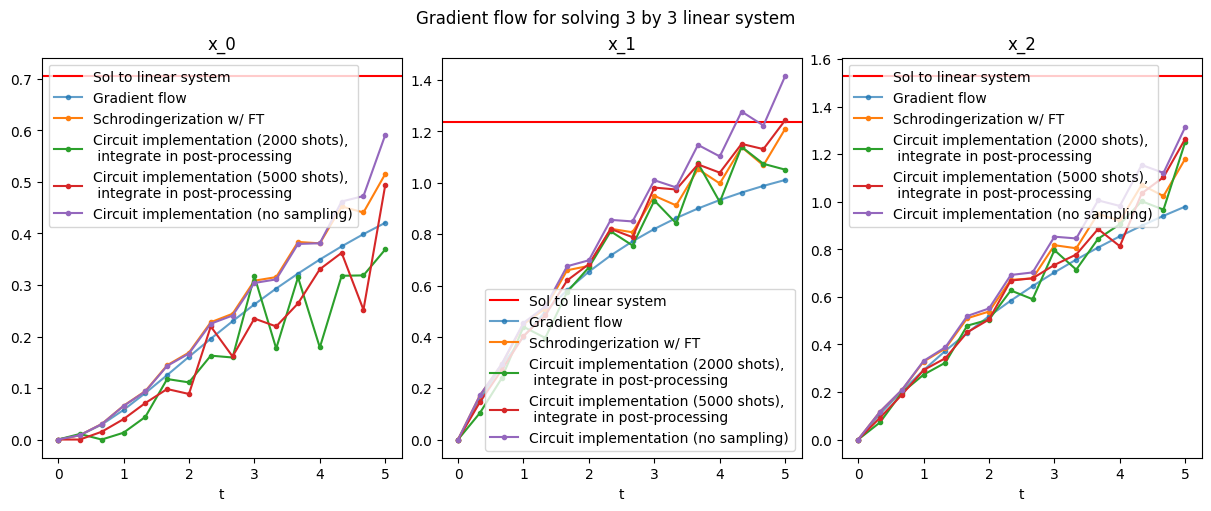

In [17]:
shots_vals = [2000, 5000]

t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(12,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)

    # axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    # axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    # axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label="Circuit implementation", markersize=3)
    
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])


# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)
# Analytical approximation of normalization factor
normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * R)) / h)
n = n_x + n_p

for shots in shots_vals:
    u_recover_circ = np.zeros((N_t, dimension))
    for i, t in enumerate(t_vals):
        print(f"Running t ={t : 0.2f}")

        # Simulate with sampling
        circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method="second_order")
        circuit.measure_all()
        compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
        # print("Depth:", compiled_circuit.depth())
        # print(compiled_circuit.count_ops())

        # Run the quantum circuit on a statevector simulator backend
        backend = Aer.get_backend('statevector_simulator')
        job = backend.run(compiled_circuit, shots=shots)
        # job = backend.run(compiled_circuit)
        result = job.result()
        
        counts = result.get_counts(compiled_circuit)
        # print(result)
        dist_sim = np.zeros(2 ** n)
        for key in counts.keys():
            bitstring = np.zeros(n, dtype=int)
            for j in range(n):
                bitstring[j] = int(key[n-1-j])
            dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
        # plt.plot(dist_sim, label="sim")


        # # Simulate without sampling
        # circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
        # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
        # # print("Depth:", compiled_circuit.depth())
        # # print(compiled_circuit.count_ops())

        # # Run the quantum circuit on a statevector simulator backend
        # backend = Aer.get_backend('statevector_simulator')
        # job = backend.run(compiled_circuit)
        # result = job.result()
        # output_state = np.array(result.get_statevector(compiled_circuit))
        # dist_ideal = np.abs(output_state)**2
        # plt.plot(dist_ideal, label="output")

        lambda_min = -norm(b)/2
        a = -lambda_min * t
        assert 0 <= a < R, "a is not within [0,R], increase R"
        a_idx = N_p // 2 + int(a / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_sim), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
        # plt.legend()
        # plt.show()

    for i in range(3):
        axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label=f"Circuit implementation ({shots} shots),\n integrate in post-processing", markersize=3)


u_recover_circ = np.zeros((N_t, dimension))
for i, t in enumerate(t_vals):
    print(f"Running t ={t : 0.2f}")

    # Simulate without sampling
    circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method="second_order")
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
    # print("Depth:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit)
    result = job.result()
    output_state = np.array(result.get_statevector(compiled_circuit))
    dist_ideal = np.abs(output_state)**2

    lambda_min = -norm(b)/2
    a = -lambda_min * t
    assert 0 <= a < R, "a is not within [0,R], increase R"
    
    a_idx = N_p // 2 + int(a / h)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_ideal), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
    # plt.legend()
    # plt.show()
for i in range(3):
    axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label=f"Circuit implementation (no sampling)", markersize=3)


for i in range(3):
    axs[i].legend()
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [18]:
# t = 0
# # normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * R)) / h)
# normalization_factor_state_prep = np.linalg.norm(np.exp(-np.abs(p)))
# # state_prep_circuit = QuantumCircuit(n_p)
# # for i in range(n_p-1):
# #     theta = 2 * np.arccos(1 / np.sqrt(1 + np.exp(-2 * (2 ** i) * h)))
# #     state_prep_circuit.ry(theta, i)
# # # Make symmetric
# # state_prep_circuit.h(n_p - 1)
# # for i in range(n_p-1):
# #     state_prep_circuit.cnot(n_p - 1, i)
# # state_prep_circuit.x(n_p - 1)


# lambda_min = -norm(b)/2
# a = -lambda_min * t
# print(f"a = {a}")
# assert 0 <= a < R, "a is not within [0,R], increase R"
# a_idx = N_p // 2 + int(a / h)
# print(f"a_idx = {a_idx}")

# # circuit = QuantumCircuit(n_x+n_p)
# # circuit.append(state_prep_circuit, qargs=range(n_p))
# # for i in np.arange(n_p, n_p + n_x):
# #     circuit.x(i)
# circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, -R, R)
# # Integration before measurement
# measurement_circuit, normalization_factor_measurement, c, c_idx = get_measurement_circuit(a_idx, n_p, R)
# circuit.append(measurement_circuit, qargs=list(range(n_p)))

# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)

# backend = Aer.get_backend('statevector_simulator')
# job = backend.run(compiled_circuit)
# result = job.result()
# output_state = np.array(result.get_statevector(compiled_circuit))
# dist_ideal = np.abs(output_state)**2

# plt.plot(output_state)
# plt.show()
# sol = (normalization_factor_state_prep * np.exp(c) * (normalization_factor_measurement ** 2) * np.sqrt(np.reshape(dist_ideal, newshape=(dimension + 1, N_p))[:,0].real) * h)[:]
# print(sol)

# # amplitudes = np.reshape(dist_sim, newshape=(dimension + 1, N_p))[:,0]
# # without integration before measurement
# # plt.plot(normalization_factor_state_prep * np.sqrt(np.sum(np.reshape((dist_ideal), newshape=(dimension + 1, N_p)), axis=0)))
# # plt.show()

# # sol = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_ideal), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:].real
# # print(sol)

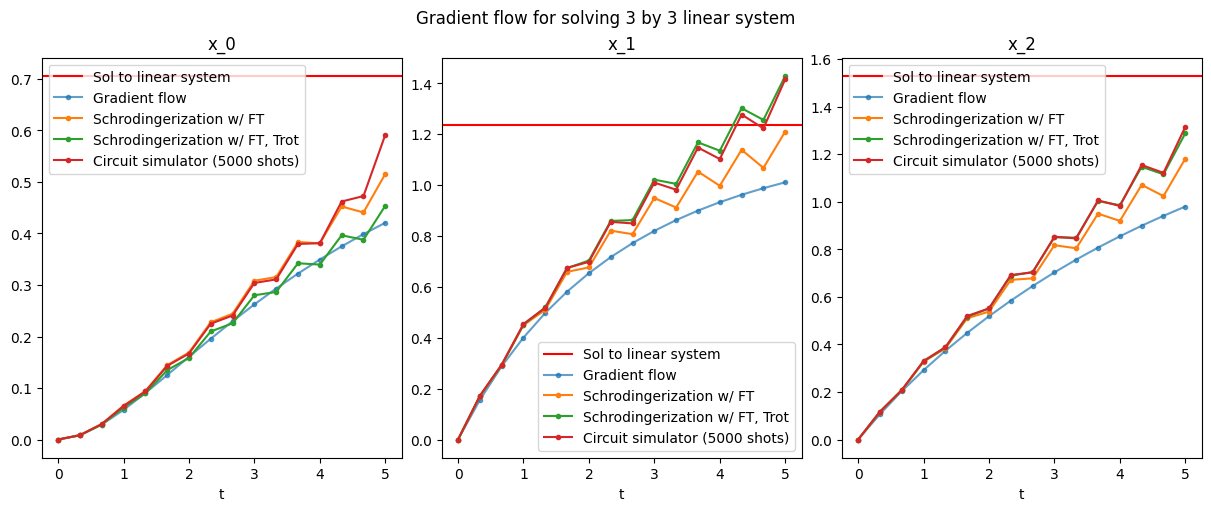

In [19]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(12,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)

    # axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label=f"Circuit simulator ({shots} shots)", markersize=3)
    
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [24]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method="second_order")
# circuit.measure_all()
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2)
print(compiled_circuit.count_ops())

# Check that SWAP gates are not removed by Qiskit transpiler
A = Operator(circuit).to_matrix()
B = Operator(compiled_circuit).to_matrix()
assert 1 - np.abs(np.trace(A @ np.conj(B.T))) / 2 ** (n_p+n_x) < 1e-6, "Check compiled circuit"

OrderedDict([('rxx', 91), ('ry', 56), ('rz', 41), ('rx', 26), ('swap', 6)])


TODO: process swaps virtually

In [12]:
filename = "schrodingerization_std_binary.qasm"
save_as_native_circuit(filename, compiled_circuit)

Saving file as schrodingerization_std_binary.qasm.
1q: 150, 2q: 53


In [43]:
circuit = QuantumCircuit(2)
circuit.rxx(0.2, 0, 1)
circuit.rx(0.1, 0)
circuit.rxx(0.2, 0, 1)
circuit.rx(0.1, 0)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=3)

In [44]:
compiled_circuit.draw()

┌───────────┐┌─────────┐┌───────────┐
q_0: ┤0          ├┤ Rx(0.2) ├┤0          ├
     │  Rxx(0.2) │└─────────┘│  Rxx(0.2) │
q_1: ┤1          ├───────────┤1          ├
     └───────────┘           └───────────┘